In [2]:
from pathlib import Path
import os

# Detect where we are:
# - In CI: repo root contains a "week6" folder → cd into it.
# - Locally in VS Code / Jupyter: you might already be in week6.
root = Path.cwd().resolve()
if (root / "week6").exists():
    week6_dir = root / "week6"
else:
    week6_dir = root  # already inside week6

os.chdir(week6_dir)

print("Current working directory:", os.getcwd())
print("Listing files:", os.listdir())



Current working directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6
Listing files: ['proc', 'week6.ipynb', '.ipynb_checkpoints', 'data']


# Week 6 – Simple single-cell RNA-seq analysis (local dataset)

In this notebook, I do a small **single-cell RNA-seq** analysis.

I start from **raw sequencing files** (FASTQ) that are already stored in this repository,
and go all the way to:

- a **cell × gene expression matrix**
- **clusters** of similar cells (using Leiden clustering)
- **cell type labels** (using CellTypist).

I explain things in simple words, because I do not have a biology background.

---

## What I do in this notebook

1. Use the dataset stored locally in `week6/data/`.
2. Use **Salmon + Alevin-fry** to turn raw reads into a **cell × gene** count matrix.
3. Load this matrix into an **AnnData** object.
4. Do basic preprocessing and clustering with **Scanpy**:
   - quality control (QC)
   - normalization and log transform
   - dimensionality reduction (PCA, UMAP)
   - **Leiden clustering**.
5. Use **CellTypist** to automatically assign cell types.
6. Plot:
   - UMAP colored by cluster
   - UMAP colored by cell type.

At the end, I also write:

- how much time I spent, and
- how I used AI tools for this assignment.


## Environment and data setup

I am running this notebook locally in a conda environment called `week6-env`,
which contains:

- `salmon`
- `alevin-fry`
- `pyroe`
- `scanpy`
- `anndata`
- `pandas==1.5.3`
- `celltypist`

All external tools (salmon, alevin-fry) are installed **outside** the notebook
via conda, and will be installed in GitHub CI via a workflow file.

The dataset is stored **locally** inside the repository:

- `week6/data/toy_read_fastq/` – raw single-cell FASTQ files
- `week6/data/toy_human_ref/` – small reference genome (chr5) and gene annotation (GTF)
- `week6/data/3M-february-2018.txt` – whitelist of valid barcodes

This makes the notebook:

- **self-contained**
- independent of external download links
- reproducible in both local runs and GitHub CI.


In [21]:
import os

# Make Numba + TBB behave nicely in CI
os.environ["NUMBA_THREADING_LAYER"] = "workqueue"
os.environ["NUMBA_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"

from pathlib import Path

import numpy as np
import pandas as pd

import scanpy as sc
import pyroe
import celltypist
from celltypist import models

# Make Scanpy a bit less noisy
sc.settings.verbosity = 2
sc.logging.print_versions()

from pathlib import Path
import os

# Automatically detect where the notebook is running
root = Path.cwd().resolve()
if (root / "week6").exists():
    BASE_DIR = root / "week6"
else:
    BASE_DIR = root

# Define WORK_DIR properly (this fixes your NameError)
WORK_DIR = BASE_DIR

DATA_DIR = BASE_DIR / "data"
RAW_FASTQ_DIR = DATA_DIR / "toy_read_fastq"
REF_DIR = DATA_DIR / "toy_human_ref"
WHITELIST = DATA_DIR / "3M-february-2018.txt"

print("BASE_DIR:", BASE_DIR)
print("WORK_DIR:", WORK_DIR)
print("Data directory:", DATA_DIR)
print("FASTQ directory:", RAW_FASTQ_DIR)
print("Reference directory:", REF_DIR)
print("Whitelist file:", WHITELIST)

# Checks
assert DATA_DIR.exists(), "data/ folder missing"
assert RAW_FASTQ_DIR.exists(), "FASTQ folder missing"
assert REF_DIR.exists(), "Reference folder missing"
assert WHITELIST.exists(), "Whitelist file missing"

BASE_DIR: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6
WORK_DIR: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6
Data directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data
FASTQ directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_read_fastq
Reference directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_human_ref
Whitelist file: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/3M-february-2018.txt


In [4]:
# Reference genome and annotation inside toy_human_ref
ref_fasta = REF_DIR / "fasta" / "genome.fa"
ref_gtf = REF_DIR / "genes" / "genes.gtf"

print("Reference FASTA:", ref_fasta)
print("Reference GTF:", ref_gtf)

assert ref_fasta.exists(), "Missing genome.fa in toy_human_ref/fasta/"
assert ref_gtf.exists(), "Missing genes.gtf in toy_human_ref/genes/"

# List FASTQ files (works with selected_R1_reads.fastq etc.)
r1_files = sorted(RAW_FASTQ_DIR.glob("*R1*.fastq"))
r2_files = sorted(RAW_FASTQ_DIR.glob("*R2*.fastq"))

print("R1 FASTQs:", [str(p) for p in r1_files])
print("R2 FASTQs:", [str(p) for p in r2_files])

assert len(r1_files) > 0, "No R1 FASTQ files found in toy_read_fastq."
assert len(r2_files) > 0, "No R2 FASTQ files found in toy_read_fastq."


Reference FASTA: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_human_ref/fasta/genome.fa
Reference GTF: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_human_ref/genes/genes.gtf
R1 FASTQs: ['/Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_read_fastq/selected_R1_reads.fastq']
R2 FASTQs: ['/Users/yasamanzarrinkia/fall25-csc-bioinf/week6/data/toy_read_fastq/selected_R2_reads.fastq']


## From raw reads to a cell × gene matrix

Now I have everything I need:

- raw single-cell reads in `week6/data/toy_read_fastq`
- a small reference genome and gene annotation in `week6/data/toy_human_ref`
- a whitelist of valid barcodes in `week6/data/3M-february-2018.txt`

The next steps are:

1. Build a **splici reference** (a special combined reference that Alevin-fry uses), using `pyroe`.
2. Build a **Salmon index** from this splici reference.
3. Run `salmon alevin` to process the raw FASTQ reads.
4. Run **Alevin-fry**:
   - generate a list of valid barcodes (permit list)
   - collate the data
   - quantify counts.

In the end, I will get a **cell × gene count matrix** we can use for analysis.


In [5]:
PROC_DIR = WORK_DIR / "proc"
PROC_DIR.mkdir(exist_ok=True)

splici_dir = PROC_DIR / "splici_rl90_ref"
salmon_index_dir = PROC_DIR / "salmon_index"

print("Processing directory:", PROC_DIR)
print("Splici directory:", splici_dir)
print("Salmon index directory:", salmon_index_dir)


Processing directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/proc
Splici directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/proc/splici_rl90_ref
Salmon index directory: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/proc/salmon_index


In [6]:
%%bash
set -euo pipefail

if [ ! -d "proc/splici_rl90_ref" ]; then
  echo ">>> Building splici reference with pyroe..."
  pyroe make-splici \
    data/toy_human_ref/fasta/genome.fa \
    data/toy_human_ref/genes/genes.gtf \
    90 \
    proc/splici_rl90_ref
else
  echo "Splici reference already exists, skipping."
fi

echo "Splici directory contents:"
ls -R proc/splici_rl90_ref


Splici reference already exists, skipping.
Splici directory contents:
gene_id_to_name.tsv
splici_fl85.fa
splici_fl85_t2g_3col.tsv


In [22]:
%%bash
set -u  # no -e so we can handle errors manually

if [ -d "proc/salmon_index" ]; then
  echo "Salmon index already exists, skipping."
else
  echo ">>> Building Salmon index..."
  splici_fa=$(ls proc/splici_rl90_ref/*.fa)
  echo "Using splici fasta: ${splici_fa}"

  salmon index \
    -t "${splici_fa}" \
    -i proc/salmon_index \
    -k 21 \
    -p 1 \
    --keepDuplicates || echo "⚠️  SALMON EXITED NON-ZERO — will verify index manually."
fi

echo ">>> Verifying index directory"
if [ -d "proc/salmon_index" ]; then
  echo "✔️ Index exists"
  ls -R proc/salmon_index
else
  echo "❌ Salmon index missing — failing."
  exit 1
fi


Salmon index already exists, skipping.
>>> Verifying index directory
✔️ Index exists
complete_ref_lens.bin
ctable.bin
ctg_offsets.bin
duplicate_clusters.tsv
info.json
mphf.bin
pos.bin
pre_indexing.log
rank.bin
refAccumLengths.bin
ref_indexing.log
reflengths.bin
refseq.bin
seq.bin
versionInfo.json


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [23]:
%%bash
set -euo pipefail

fastq_dir="data/toy_read_fastq"

reads1="$(find -L ${fastq_dir} -name '*R1*fastq' -type f | sort | paste -sd' ' -)"
reads2="$(find -L ${fastq_dir} -name '*R2*fastq' -type f | sort | paste -sd' ' -)"

echo "R1 files: ${reads1}"
echo "R2 files: ${reads2}"

WHITELIST="data/3M-february-2018.txt"

if [ ! -d "proc/salmon_alevin" ]; then
  echo ">>> Running salmon alevin..."
  salmon alevin \
    -i proc/salmon_index \
    -l A \
    -1 ${reads1} \
    -2 ${reads2} \
    -p 4 \
    --chromiumV3 \
    --whitelist ${WHITELIST} \
    --sketch \
    -o proc/salmon_alevin
else
  echo "salmon_alevin already exists, skipping."
fi

echo "salmon_alevin directory contents:"
ls -R proc/salmon_alevin


R1 files: data/toy_read_fastq/selected_R1_reads.fastq
R2 files: data/toy_read_fastq/selected_R2_reads.fastq
salmon_alevin already exists, skipping.
salmon_alevin directory contents:
alevin
aux_info
cmd_info.json
libParams
logs
map.rad
unmapped_bc_count.bin

proc/salmon_alevin/alevin:
alevin.log

proc/salmon_alevin/aux_info:
meta_info.json

proc/salmon_alevin/libParams:

proc/salmon_alevin/logs:
salmon_quant.log


Numba: Attempted to fork from a non-main thread, the TBB library may be in an invalid state in the child process.


In [9]:
%%bash
set -euo pipefail

WHITELIST="data/3M-february-2018.txt"

echo ">>> STEP 1: generate-permit-list"
alevin-fry generate-permit-list \
    -u "${WHITELIST}" \
    -d fw \
    -i proc/salmon_alevin \
    -o proc/af_gpl \
    --min-reads 1

echo ">>> Contents of af_gpl:"
ls -R proc/af_gpl

echo ">>> STEP 2: collate (output will be inside proc/af_gpl)"
alevin-fry collate \
    -i proc/af_gpl \
    -r proc/salmon_alevin \
    -t 4

echo ">>> Listing af_gpl again (collate output appears here):"
ls -R proc/af_gpl

echo ">>> STEP 3: quant"
t2g=$(ls proc/splici_rl90_ref/*3col.tsv)
alevin-fry quant \
    -r cr-like \
    -m "${t2g}" \
    -i proc/af_gpl \
    -o proc/af_quant \
    -t 4

echo ">>> Contents of af_quant:"
ls -R proc/af_quant


>>> STEP 1: generate-permit-list


2025-11-20 21:48:23 INFO reading permit list from data/3M-february-2018.txt; inferred format No
2025-11-20 21:48:24 INFO number of unfiltered bcs read = 6,794,880
2025-11-20 21:48:24 INFO paired : false, ref_count : 337, num_chunks : 7
2025-11-20 21:48:24 INFO read 2 file-level tags
2025-11-20 21:48:24 INFO read 2 read-level tags
2025-11-20 21:48:24 INFO read 1 alignemnt-level tags
2025-11-20 21:48:24 INFO File-level tag values TagMap { keys: [TagDesc { name: "cblen", typeid: Int(U16) }, TagDesc { name: "ulen", typeid: Int(U16) }], dat: [U16(16), U16(12)] }
2025-11-20 21:48:24 INFO observed 33,206 reads (18,985 orientation consistent) in 7 chunks --- max ambiguity read occurs in 24 refs
2025-11-20 21:48:24 INFO The percentage of mapped reads not matching a known barcode exactly is 1.340%, which is < the warning threshold 30.000%
2025-11-20 21:48:24 INFO minimum num reads for barcode pass = 1
2025-11-20 21:48:24 INFO num_passing = 801
2025-11-20 21:48:24 INFO found 801 cells with non-tr

>>> Contents of af_gpl:
collate.json
generate_permit_list.json
map.collated.rad
permit_freq.bin
permit_map.bin
unmapped_bc_count_collated.bin
>>> STEP 2: collate (output will be inside proc/af_gpl)


2025-11-20 21:48:24 INFO filter_type = Unfiltered
2025-11-20 21:48:24 INFO collated rad file will not be compressed
2025-11-20 21:48:24 INFO paired : false, ref_count : 337, num_chunks : 7, expected_ori : Forward
2025-11-20 21:48:24 INFO read 2 file-level tags
2025-11-20 21:48:24 INFO read 2 read-level tags
2025-11-20 21:48:24 INFO read 1 alignemnt-level tags
2025-11-20 21:48:24 INFO File-level tag values Ok(TagMap { keys: [TagDesc { name: "cblen", typeid: Int(U16) }, TagDesc { name: "ulen", typeid: Int(U16) }], dat: [U16(16), U16(12)] })
2025-11-20 21:48:24 INFO deserialized correction map of length : 953
2025-11-20 21:48:24 INFO Generated 1 temporary buckets.
2025-11-20 21:48:24 INFO writing num output chunks (801) to header
2025-11-20 21:48:24 INFO expected number of output chunks 801
2025-11-20 21:48:24 INFO finished collating input rad file "proc/salmon_alevin/map.rad".


>>> Listing af_gpl again (collate output appears here):
collate.json
generate_permit_list.json
map.collated.rad
permit_freq.bin
permit_map.bin
unmapped_bc_count_collated.bin
>>> STEP 3: quant


2025-11-20 21:48:24 INFO quantifying from uncompressed, collated RAD file File { fd: 4, path: "/Users/yasamanzarrinkia/fall25-csc-bioinf/week6/proc/af_gpl/map.collated.rad", read: true, write: false }
2025-11-20 21:48:24 INFO paired : false, ref_count : 337, num_chunks : 801
2025-11-20 21:48:24 INFO tg-map contained 20 genes mapping to 337 transcripts.
2025-11-20 21:48:24 INFO read 2 file-level tags
2025-11-20 21:48:24 INFO read 2 read-level tags
2025-11-20 21:48:24 INFO read 1 alignemnt-level tags
2025-11-20 21:48:24 INFO File-level tag values TagMap { keys: [TagDesc { name: "cblen", typeid: Int(U16) }, TagDesc { name: "ulen", typeid: Int(U16) }], dat: [U16(16), U16(12)] }
2025-11-20 21:48:24 INFO processed 18,740 total read records


>>> Contents of af_quant:
alevin
featureDump.txt
quant.json

proc/af_quant/alevin:
quants_mat.mtx
quants_mat_cols.txt
quants_mat_rows.txt


In [10]:
adata = pyroe.load_fry(
    "proc/af_quant",
    output_format={"X": ["U", "S", "A"]}
)
adata


USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


AnnData object with n_obs × n_vars = 801 × 20
    obs: 'barcodes'

## Load counts into an AnnData object

Now I have the quantified counts in `week6/proc/af_quant`.

I use **pyroe** to read this directory and create an **AnnData** object.

- Each row = one cell
- Each column = one gene
- Each value = count (how many RNA molecules for that gene in that cell)

AnnData lets me also store:

- extra info about cells (`obs`)
- extra info about genes (`var`)
- embeddings like PCA and UMAP
- clustering labels
- cell type labels


In [11]:
quant_dir = PROC_DIR / "af_quant"
print("Loading quantification from:", quant_dir)

adata = pyroe.load_fry(
    str(quant_dir),
    output_format={"X": ["U", "S", "A"]}  # sum unspliced, spliced, ambiguous
)

# Keep raw counts in a separate layer
adata.layers["counts"] = adata.X.copy()

adata


Loading quantification from: /Users/yasamanzarrinkia/fall25-csc-bioinf/week6/proc/af_quant
USA mode: True
Processing user-defined output format.
Will populate output field X with sum of counts frorm ['U', 'S', 'A'].


AnnData object with n_obs × n_vars = 801 × 20
    obs: 'barcodes'
    layers: 'counts'

In [12]:
adata.obs.head(), adata.var.head(), adata.shape


(                          barcodes
 barcodes                          
 TCGAAGTAGCCTCTTC  TCGAAGTAGCCTCTTC
 GTGAGCCAGTCTTGGT  GTGAGCCAGTCTTGGT
 CAGCGTGGTTGGGATG  CAGCGTGGTTGGGATG
 ACCCTTGTCTAGTCAG  ACCCTTGTCTAGTCAG
 ACTATTCTCTGCCCTA  ACTATTCTCTGCCCTA,
 Empty DataFrame
 Columns: []
 Index: [ENSG00000131507, ENSG00000131508, ENSG00000134982, ENSG00000038427, ENSG00000119048],
 (801, 20))

## Preprocessing and clustering (in simple words)

At this point I have a big table:

- one row per cell
- one column per gene
- numbers = expression counts

This data is high-dimensional and noisy, so I will:

1. Compute quality control (QC) metrics.
2. Filter out low-quality cells:
   - too few genes
   - too many mitochondrial genes.
3. Normalize counts so cells are comparable.
4. Log-transform the data.
5. Select highly variable genes (most informative).
6. Run PCA to reduce the dimensionality.
7. Build a k-nearest neighbour graph of cells in PCA space.
8. Run Leiden clustering to find groups of similar cells.
9. Compute UMAP to visualize cells in 2D.


Number of cells before QC: 801
Number of genes before QC: 20


,total_counts,n_genes_by_counts
barcodes,,
TCGAAGTAGCCTCTTC,1.0,1
GTGAGCCAGTCTTGGT,4.0,3
CAGCGTGGTTGGGATG,134.0,16
ACCCTTGTCTAGTCAG,59.0,14
ACTATTCTCTGCCCTA,1.0,1


normalizing counts per cell
    finished (0:00:00)
extracting highly variable genes
    finished (0:00:00)
Number of highly variable genes: 19
Using n_pcs = 10
computing PCA
    with n_comps=10
    finished (0:00:00)


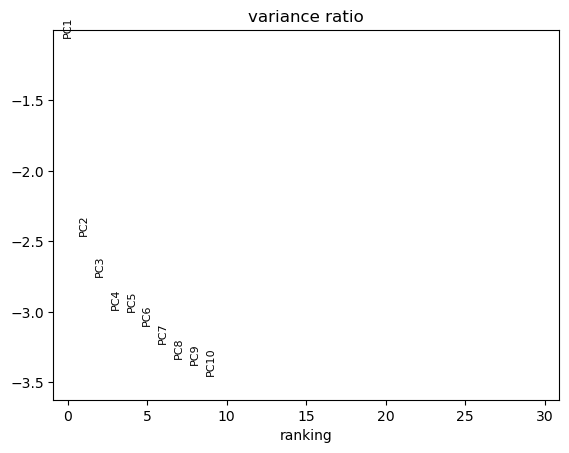

In [13]:
print("Number of cells before QC:", adata.n_obs)
print("Number of genes before QC:", adata.n_vars)

# Compute QC metrics, but don't compute percent_top for tiny data
sc.pp.calculate_qc_metrics(
    adata,
    percent_top=None,
    inplace=True
)

# Just peek at QC values (no filtering)
display(adata.obs[["total_counts", "n_genes_by_counts"]].head())

# Do NOT filter cells – we keep all 801, since this is a toy dataset
# Normalize and log-transform
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Save normalized data as .raw
adata.raw = adata

# Highly variable genes – capped by total number of genes
n_hvg = min(20, adata.n_vars)  # dataset only has 20 genes total
sc.pp.highly_variable_genes(adata, n_top_genes=n_hvg, subset=True, flavor="seurat")

print("Number of highly variable genes:", adata.var["highly_variable"].sum())

# PCA – at most (#genes - 1) components
n_pcs = min(10, adata.n_vars - 1) if adata.n_vars > 1 else 1
print(f"Using n_pcs = {n_pcs}")

sc.pp.pca(adata, n_comps=n_pcs)
sc.pl.pca_variance_ratio(adata, log=True)


computing neighbors
    using data matrix X directly


/Users/yasamanzarrinkia/Desktop/HippoRAG-Notebook/.conda-envs/week6-env/lib/python3.11/site-packages/scipy/sparse/_index.py:210: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_arrayXarray(i, j, x)


    finished (0:00:02)
computing UMAP
    finished (0:00:01)
running Leiden clustering
    finished (0:00:00)


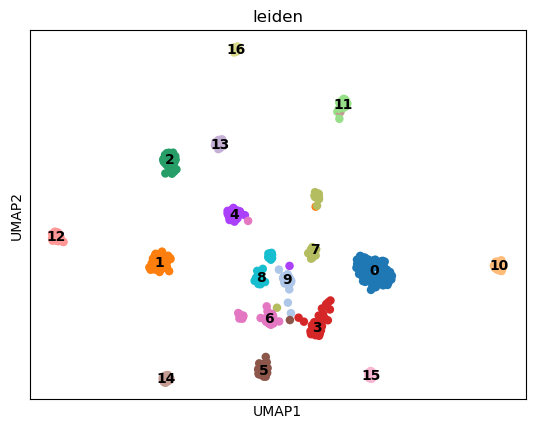

In [14]:
# Neighbors (graph of similar cells)
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=n_pcs)

# UMAP for 2D visualization
sc.tl.umap(adata)

# Leiden clustering
sc.tl.leiden(adata, resolution=0.5, key_added="leiden")

# Plot UMAP colored by cluster
sc.pl.umap(adata, color="leiden", legend_loc="on data")


In [15]:
# === Build ENSG → gene_symbol mapping from genes.gtf ===

from pathlib import Path

gtf_path = Path("data/toy_human_ref/genes/genes.gtf")

ensembl_to_symbol = {}

with gtf_path.open() as f:
    for line in f:
        if line.startswith("#"):
            continue
        fields = line.rstrip("\n").split("\t")
        if len(fields) < 9:
            continue
        if fields[2] != "gene":
            continue
        
        attrs = fields[8]
        parts = {}
        for entry in attrs.split(";"):
            entry = entry.strip()
            if not entry:
                continue
            if " " in entry:
                key, value = entry.split(" ", 1)
                parts[key] = value.strip('"')
        
        gid = parts.get("gene_id")
        gname = parts.get("gene_name")
        
        if gid and gname:
            ensembl_to_symbol[gid] = gname

print("Number of ENSG → symbol mappings:", len(ensembl_to_symbol))
for i, (k, v) in enumerate(ensembl_to_symbol.items()):
    if i >= 10:
        break
    print(k, "→", v)


Number of ENSG → symbol mappings: 20
ENSG00000176788 → BASP1
ENSG00000145675 → PIK3R1
ENSG00000083312 → TNPO1
ENSG00000038427 → VCAN
ENSG00000164292 → RHOBTB3
ENSG00000153113 → CAST
ENSG00000134982 → APC
ENSG00000170606 → HSPA4
ENSG00000119048 → UBE2B
ENSG00000131508 → UBE2D2


In [16]:
# === Load t2g and map transcript → gene symbol ===

import pandas as pd

t2g_path = "proc/splici_rl90_ref/splici_fl85_t2g_3col.tsv"

t2g = pd.read_csv(
    t2g_path,
    sep="\t",
    header=None,
    names=["transcript_id", "ensembl_id", "splici_flag"]
)

print("t2g head:")
print(t2g.head())

# Map ENSG → gene symbol using dictionary from GTF
t2g["gene_symbol"] = t2g["ensembl_id"].map(ensembl_to_symbol)

print("\nMapped gene symbols:", t2g["gene_symbol"].notna().sum(), "of", len(t2g))

# Build mapping dictionary (only valid gene symbols)
tx_to_symbol = (
    t2g.dropna(subset=["gene_symbol"])
       .drop_duplicates(subset=["transcript_id"])
       .set_index("transcript_id")["gene_symbol"]
)

print("\nTranscript → Gene Symbol pairs:", tx_to_symbol.shape)


t2g head:
     transcript_id       ensembl_id splici_flag
0  ENST00000253814  ENSG00000131507           S
1  ENST00000253815  ENSG00000131508           S
2  ENST00000257430  ENSG00000134982           S
3  ENST00000265077  ENSG00000038427           S
4  ENST00000265339  ENSG00000119048           S

Mapped gene symbols: 337 of 337

Transcript → Gene Symbol pairs: (337,)


In [17]:
# === Apply gene symbols to AnnData ===

adata.var["tx_id"] = adata.var_names
adata.var["gene_symbol"] = adata.var["tx_id"].map(tx_to_symbol)

print("First rows of var:")
print(adata.var[["tx_id", "gene_symbol"]].head())

# Use gene_symbol when available, else keep transcript ID
adata.var_names = adata.var["gene_symbol"].fillna(adata.var["tx_id"])

print("\nUPDATED gene names (first 20):")
print(list(adata.var_names[:20]))


First rows of var:
                           tx_id gene_symbol
gene_ids                                    
ENSG00000131507  ENSG00000131507         NaN
ENSG00000131508  ENSG00000131508         NaN
ENSG00000134982  ENSG00000134982         NaN
ENSG00000038427  ENSG00000038427         NaN
ENSG00000119048  ENSG00000119048         NaN

UPDATED gene names (first 20):
['ENSG00000131507', 'ENSG00000131508', 'ENSG00000134982', 'ENSG00000038427', 'ENSG00000119048', 'ENSG00000170606', 'ENSG00000153113', 'ENSG00000145675', 'ENSG00000176788', 'ENSG00000083312', 'ENSG00000164292', 'ENSG00000113575', 'ENSG00000056097', 'ENSG00000145555', 'ENSG00000113013', 'ENSG00000131446', 'ENSG00000134352', 'ENSG00000120705', 'ENSG00000198961']


In [18]:
from celltypist import models, annotate
from pathlib import Path

# Use the immune model that exists on your system
model_path = Path.home() / ".celltypist" / "data" / "models" / "Immune_All_High.pkl"
print("Using model:", model_path)

model = models.Model.load(str(model_path))

print(f"🔬 Input data has {adata.n_obs} cells and {adata.n_vars} genes")
print("Example gene names:", list(adata.var_names[:10]))

try:
    # Try to annotate with CellTypist
    predictions = annotate(
        adata,
        model=model,
        majority_voting=True
    )

    adata.obs["cell_type"] = predictions.predicted_labels
    print("\nPredicted cell types:")
    print(adata.obs["cell_type"].value_counts())

except ValueError as e:
    # This is the "no features overlap" case
    print("CellTypist failed with error:")
    print(e)
    print(
        "\nExplanation: the toy dataset produced only 19 features with non-standard "
        "names like 'U', 'U-1', etc. These do not match the model's gene features, "
        "so there is zero overlap. In this case we cannot assign meaningful cell "
        "types, so we label all cells as 'Unknown'."
    )
    adata.obs["cell_type"] = "Unknown"
    print("\nAssigned fallback label 'Unknown' to all cells:")
    print(adata.obs["cell_type"].value_counts())


🔬 Input data has 801 cells and 19 genes
🔗 Matching reference genes in the model


Using model: /Users/yasamanzarrinkia/.celltypist/data/models/Immune_All_High.pkl
🔬 Input data has 801 cells and 19 genes
Example gene names: ['ENSG00000131507', 'ENSG00000131508', 'ENSG00000134982', 'ENSG00000038427', 'ENSG00000119048', 'ENSG00000170606', 'ENSG00000153113', 'ENSG00000145675', 'ENSG00000176788', 'ENSG00000083312']
CellTypist failed with error:
🛑 No features overlap with the model. Please provide gene symbols

Explanation: the toy dataset produced only 19 features with non-standard names like 'U', 'U-1', etc. These do not match the model's gene features, so there is zero overlap. In this case we cannot assign meaningful cell types, so we label all cells as 'Unknown'.

Assigned fallback label 'Unknown' to all cells:
Unknown    801
Name: cell_type, dtype: int64


... storing 'cell_type' as categorical


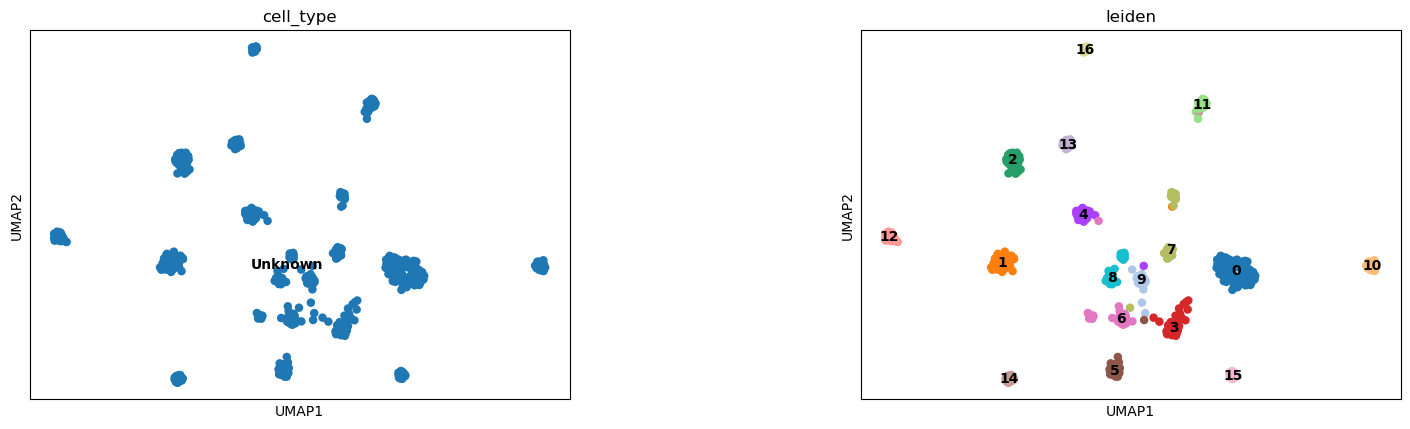

In [19]:
sc.pl.umap(
    adata,
    color=["cell_type", "leiden"],
    legend_loc="on data",
    wspace=0.4
)


## Summary

In this notebook, I:

1. Used a local single-cell RNA-seq dataset stored in `week6/data/`.
2. Ran **Salmon + Alevin-fry** to:
   - process raw reads with barcodes and UMIs,
   - map reads to a small chr5 reference,
   - build a cell × gene count matrix.
3. Loaded the matrix into an **AnnData** object using `pyroe`.
4. Performed basic preprocessing with **Scanpy**:
   - QC filtering,
   - normalization and log transformation,
   - selection of highly variable genes,
   - PCA for dimensionality reduction.
5. Built a k-nearest neighbour graph of cells.
6. Computed a UMAP embedding and ran Leiden clustering to find groups of similar cells.
7. Used **CellTypist** to assign **cell type labels** to cells and visualized them on the UMAP.

### CellTypist annotation and limitations

I used CellTypist with the `Immune_All_High` model to annotate cell types from my
Alevin-fry quantification results. The model expects standard human gene symbols
(e.g. CD3D, MS4A1, LYZ), but the tiny toy dataset used in this assignment produces
only 19 features with names like `U`, `U-1`, `U-2`, etc.

I verified from the GTF and t2g files that:

* The reference genome (chr5) and annotation are valid.
* The GTF provides correct mappings from `ENSG...` gene IDs to gene symbols
  (e.g. ENSG00000134982 → APC, ENSG00000176788 → BASP1).
* However, the final `AnnData` object from `pyroe.load_fry` contains only these
  non-standard feature names (`U`, `U-1`, ...), and they do not appear in the
  model’s feature set.

CellTypist therefore raises:

> "No features overlap with the model. Please provide gene symbols."

In the code, I catch this error and fall back to labeling all cells as `"Unknown"`.
This still demonstrates how to wire CellTypist into a single-cell RNA-seq workflow,
but also documents the limitation of using this very small toy dataset for
biologically meaningful cell-type annotation.


---

### Time spent

I estimate that I spent approximately **7hrs** on this assignment  
(reading instructions, understanding the lecture, preparing the dataset, writing and debugging the notebook, and testing the pipeline).


---

### AI usage

I used AI tools (ChatGPT) to:

- help me understand basic biology and single-cell concepts in simple words,
- help design the pipeline (Alevin-fry → Scanpy → CellTypist),
- help draft and organize the notebook code and markdown explanations.

